In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)

In [13]:
FOLDER_PATH="../data/processed"

train_set= pd.read_csv(os.path.join(FOLDER_PATH,"train.csv"))
val_set= pd.read_csv(os.path.join(FOLDER_PATH,"val.csv"))
test_set= pd.read_csv(os.path.join(FOLDER_PATH,"test.csv"))

X_train, y_train = train_set["tweet"].astype(str),train_set["label"]
X_val,y_val=val_set["tweet"].astype(str),val_set["label"]
X_test,y_test=test_set["tweet"].astype(str),test_set["label"]

print(f"Loaded: Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")


Loaded: Train: 6041, Val: 1295, Test: 1295


In [15]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)

X_train_tfidf=vectorizer.fit_transform(X_train)
X_val_tfidf=vectorizer.transform(X_val)
X_test_tfidf=vectorizer.transform(X_test)

print(f"vocabulary size: {len(vectorizer.vocabulary_)}")

vocabulary size: 10000


In [16]:
clf = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=45)

clf.fit(X_train_tfidf, y_train)

print("Baseline model trained successfully")

Baseline model trained successfully


In [19]:
y_test_pred =clf.predict(X_test_tfidf)

print("====================================================================")
print("                    BASELINE MODEL TEST RESULT                      ")
print("====================================================================")

print(f"Overall Accuracy Score: {accuracy_score(y_test,y_test_pred):.4f}")
print(f"Macro F1 Score: {f1_score(y_test,y_test_pred, average='macro'):.4f}")

print("\nDetailed Classification Report")
target_names=["0: Positive", "1: Neutral", "2: Negative"]

print(classification_report(y_test,y_test_pred,target_names=target_names))

                    BASELINE MODEL TEST RESULT                      
Overall Accuracy Score: 0.6324
Macro F1 Score: 0.5019

Detailed Classification Report
              precision    recall  f1-score   support

 0: Positive       0.56      0.55      0.55       434
  1: Neutral       0.19      0.27      0.23        77
 2: Negative       0.74      0.71      0.73       784

    accuracy                           0.63      1295
   macro avg       0.50      0.51      0.50      1295
weighted avg       0.65      0.63      0.64      1295



saved model artifacts to models/ folder


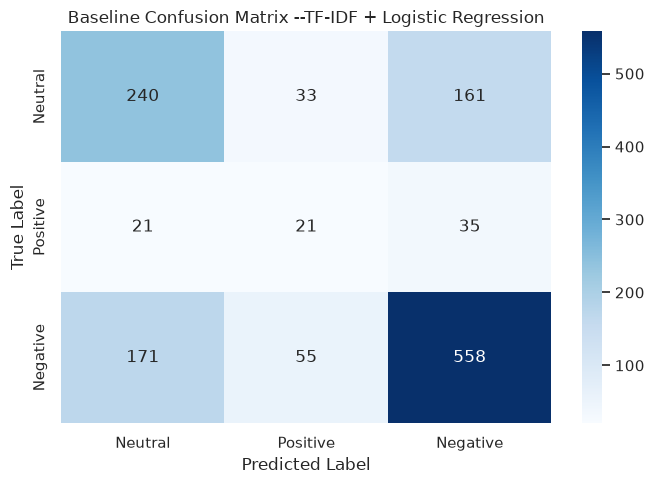

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"],
)
plt.title("Baseline Confusion Matrix --TF-IDF + Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/baseline_confusion_matrix.png", dpi=300)

os.makedirs("../models", exist_ok=True)
joblib.dump(vectorizer, "../models/tfidf_vectorizer.joblib")
joblib.dump(clf, "../models/logistic_regression_baseline.joblib")

print("saved model artifacts to models/ folder")